In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def linear(x, w, b):
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    return np.dot(x, w) + b

In [5]:
def activation(z):
    return np.maximum(0 ,z) #try 0.01 and 0.001 for leaky relu

In [6]:
def backprop(x, y, y_pred, z1, a1, w2):
    N = len(x)
    dL_dy_pred = 2.0 * (y_pred - y) / N  # Average gradient

    dw2 = np.dot(a1.T, dL_dy_pred)        # Do NOT divide by N again here
    db2 = np.sum(dL_dy_pred, axis=0, keepdims=True)

    dL_da1 = np.dot(dL_dy_pred, w2.T)
    dL_dz1 = dL_da1 * (z1 > 0)

    dw1 = np.dot(x.T, dL_dz1)             # Do NOT divide by N again here
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    return dw1, db1, dw2, db2

In [7]:
def init():
    w1 = np.random.randn(1, 50) * np.sqrt(2.0 / 1)
    b1 = np.zeros((1, 50))

    w2 = np.random.randn(50, 1) * np.sqrt(2.0 / 50)
    b2 = np.zeros((1, 1))
    
    return w1, b1, w2, b2

In [8]:
def model_train_k1(x, y):
    learning_rate = 0.001
    x = np.array(x, dtype=np.float64).reshape(-1, 1)
    y = np.array(y, dtype=np.float64).reshape(-1, 1)
    w1, b1, w2, b2 = init()
    if y.ndim == 1: y = y.reshape(-1, 1)
    for i in range(10000):
        # Forward Pass
        z1 = linear(x, w1, b1)
        a1 = np.maximum(0, z1)
        y_pred = linear(a1, w2, b2)
        loss = np.mean((y - y_pred) ** 2)
        print("Loss is", loss)
        # Backpropagation
        dw1, db1, dw2, db2 = backprop(x, y, y_pred, z1, a1, w2)
        # Updates
        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2
    return w1, b1, w2, b2

In [9]:
step = 0.001
iter = 20001
start = -10
end = 1
x_data = np.array([])
y_data = np.array([])
for i in range(iter):
    x_data = np.append(x_data, [start])
    y_data = np.append(y_data, [np.square(start)])
    start = start + step
x_data = x_data.reshape(-1, 1)
y_data = y_data.reshape(-1, 1)
trained_w1, trained_b1, trained_w2, trained_b2 = model_train_k1(x_data, y_data)

Loss is 2013.8303597722036
Loss is 515.9039905856808
Loss is 331.0425629839114
Loss is 198.39868918726629
Loss is 155.34330392213946
Loss is 135.47844858243445
Loss is 128.71072796656972
Loss is 125.9598223549531
Loss is 124.89777250348224
Loss is 124.41041114592082
Loss is 124.14348911825279
Loss is 123.95501347948893
Loss is 123.79578393997647
Loss is 123.64724439542294
Loss is 123.50275841992168
Loss is 123.35987804589661
Loss is 123.21771750957348
Loss is 123.0759519897389
Loss is 122.93446250998569
Loss is 122.79320449078973
Loss is 122.65216061773374
Loss is 122.51132320255171
Loss is 122.37068831499793
Loss is 122.23025325336914
Loss is 122.09001576404172
Loss is 121.94997389118166
Loss is 121.81012558335708
Loss is 121.67046899631578
Loss is 121.53100232668471
Loss is 121.39172345139941
Loss is 121.25263075066874
Loss is 121.1137221948424
Loss is 120.97499599659238
Loss is 120.83645046314238
Loss is 120.6980836416152
Loss is 120.55989387606523
Loss is 120.42187921517454
Loss is

In [33]:
def scale_quant(r, S, Z, qmin, qmax):
    return np.clip(np.round(r/S)+Z, qmin, qmax)

def pt_quantization(trained_w1, trained_b1, trained_w2, trained_b2, bitlength):
    rmax = max(np.max(trained_w1), np.max(trained_b1), np.max(trained_w2), np.max(trained_b2))
    rmin = min(np.min(trained_w1), np.min(trained_b1), np.min(trained_w2), np.min(trained_b2))
    qmax = ((1<<(bitlength-1)))-1
    qmin = -qmax - 1
    S = (rmax-rmin)/(qmax-qmin)
    Z = np.round(qmin-rmin/S)
    quant_w1 = scale_quant(trained_w1, S, Z, qmin, qmax)
    quant_b1 = scale_quant(trained_b1, S, Z, qmin, qmax)
    quant_w2 = scale_quant(trained_w2, S, Z, qmin, qmax)
    quant_b2 = scale_quant(trained_b2, S, Z, qmin, qmax)
    return quant_w1, quant_b1, quant_w2, quant_b2, S, Z

def input_quantization(w1, b1, bitlength, x_data, S_w, Z_w):
    x_new = np.array(x_data, dtype=np.float64).reshape(-1, 1)
    dequant_w1 = S_w * (w1 - Z_w)
    dequant_b1 = S_w * (b1 - Z_w)
    a1 = activation(linear(x_new, dequant_w1, dequant_b1))
    rmax = np.max(a1)
    rmin = np.min(a1)
    qmax = (1<<(bitlength-1)) - 1
    qmin = -qmax -1
    S = (rmax-rmin)/(qmax-qmin)
    Z = np.round(qmin-rmin/S)
    return S, Z, qmin, qmax

def quantize_k(trained_w1, trained_b1, trained_w2, trained_b2, bitlength, x_data):
    quant_w1, quant_b1, quant_w2, quant_b2, S_w, Z_w = pt_quantization(trained_w1, trained_b1, trained_w2, trained_b2, bitlength)
    
    sample_size = max(1, int(len(x_data) * 0.10))
    random_indices = np.random.choice(len(x_data), size=sample_size, replace=False)
    x_sample = x_data[random_indices].reshape(-1, 1)
    
    S, Z, qmin, qmax = input_quantization(quant_w1, quant_b1, bitlength, x_sample, S_w, Z_w)
    return quant_w1, quant_b1, quant_w2, quant_b2, S_w, Z_w, qmin, qmax

def CLE(trained_w1, trained_b1, trained_w2):
    r1 = np.abs(trained_w1)
    r2 = np.abs(trained_w2).reshape(r1.shape)
    s = np.sqrt(r2/r1+1e-8)
    return trained_w1*s, trained_b1*s, trained_w2/s.reshape(trained_w2.shape)

In [10]:
def predict(x_new, w1, b1, w2, b2):
    x_new = np.array(x_new, dtype=np.float64).reshape(-1, 1)
    a1 = activation(linear(x_new, w1, b1))
    y_pred = linear(a1, w2, b2)
    return y_pred

Number of points retained: 31345
Total points tested: 100000


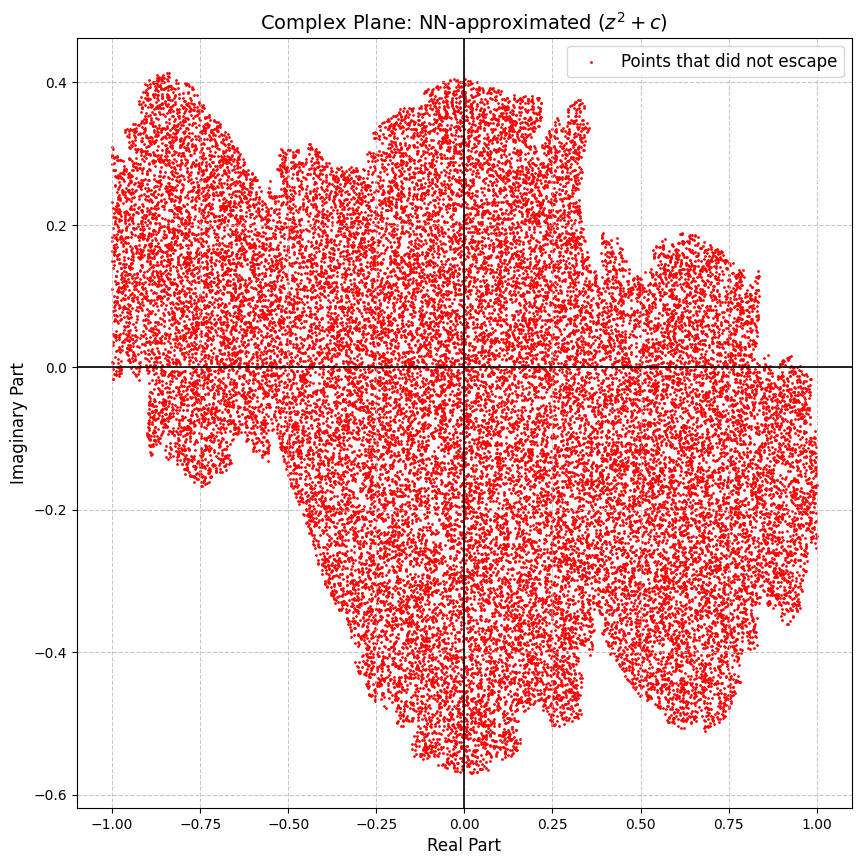

In [34]:
import numpy as np
import matplotlib.pyplot as plt

#YES QUANTIZE
cle_w1, cle_b1, cle_w2 = CLE(trained_w1, trained_b1, trained_w2)
quant_w1, quant_b1, quant_w2, quant_b2, S, Z, qmin, qmax = quantize_k(cle_w1, cle_b1, cle_w2, trained_b2, 8, x_data)
real_test = np.random.uniform(-1, 1, 100000)
imag_test = np.random.uniform(-1, 1, 100000)

n_iters = 25
bailout = 2.0

# c is now a single fixed constant for the whole set
c_real, c_imag = -0.8, 0.156   # classic dendrite-like Julia set

# z starts AT the sampled point instead of at 0
z_real = real_test.copy()
z_imag = imag_test.copy()
escaped = np.zeros(len(real_test), dtype=bool)
dw1 = S * (quant_w1 - Z)
db1 = S * (quant_b1 - Z)
dw2 = S * (quant_w2 - Z)
db2 = S * (quant_b2 - Z)

for i in range(n_iters):
    #YES QUANTIZE
    zr_sq = predict(z_real, dw1, db1, dw2, db2).flatten()
    zi_sq = predict(z_imag, dw1, db1, dw2, db2).flatten()
    
    #NO QUANTIZE
    #zr_sq = predict(z_real, trained_w1, trained_b1, trained_w2, trained_b2).flatten()
    #zi_sq = predict(z_imag, trained_w1, trained_b1, trained_w2, trained_b2).flatten()
    #zr_sq = z_real **2
    #zi_sq = z_imag **2

    new_real = zr_sq - zi_sq + c_real
    new_imag = 2 * z_real * z_imag + c_imag

    active = ~escaped
    z_real[active] = new_real[active]
    z_imag[active] = new_imag[active]

    mag = np.sqrt(z_real**2 + z_imag**2)
    newly_escaped = (~escaped) & (mag > bailout)
    escaped |= newly_escaped
    z_real[escaped] = bailout * 2
    z_imag[escaped] = bailout * 2

mask = ~escaped
x_filtered = np.column_stack((real_test, imag_test))[mask]

# Plotting on the Complex Plane
plt.figure(figsize=(10, 10))

plt.scatter(x_filtered[:, 0], x_filtered[:, 1], color='red', marker='o',
            label='Points that did not escape', s=1)

plt.xlabel('Real Part', fontsize=12)
plt.ylabel('Imaginary Part', fontsize=12)
plt.title('Complex Plane: NN-approximated ($z^2 + c$)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

print("Number of points retained:", len(x_filtered))
print("Total points tested:", len(real_test))

# Make axes pass through the origin for better visualization
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

plt.show()

In [35]:
def escape_time_grid(c_real, c_imag, dw1, db1, dw2, db2,
                      xmin=-1.5, xmax=1.5, ymin=-1.5, ymax=1.5,
                      res=350, max_iter=40, bailout=2.0):
    """Escape-time grid for z -> z^2 + c, using the trained NN in place of
    literal squaring: (a+bi)^2 = (a^2 - b^2) + (2ab)i."""
    real_axis = np.linspace(xmin, xmax, res)
    imag_axis = np.linspace(ymin, ymax, res)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)

    z_real = real_grid.flatten().astype(np.float64)
    z_imag = imag_grid.flatten().astype(np.float64)

    escape_iter = np.full(z_real.shape, max_iter, dtype=np.float64)
    escaped = np.zeros(z_real.shape, dtype=bool)
    bailout_sq = bailout ** 2

    for i in range(max_iter):
        zr_sq = predict(z_real, dw1, db1, dw2, db2).flatten()
        zi_sq = predict(z_imag, dw1, db1, dw2, db2).flatten()

        new_real = zr_sq - zi_sq + c_real
        new_imag = 2 * z_real * z_imag + c_imag

        active = ~escaped
        z_real[active] = new_real[active]
        z_imag[active] = new_imag[active]

        mag_sq = z_real ** 2 + z_imag ** 2
        newly_escaped = (~escaped) & (mag_sq > bailout_sq)
        escape_iter[newly_escaped] = i
        escaped |= newly_escaped

        # freeze escaped points so they don't blow up / NaN later
        z_real[escaped] = bailout * 2
        z_imag[escaped] = bailout * 2

    return escape_iter.reshape(res, res)

In [36]:
# Sweep c = 0.7885 * e^(i*a) for a in [0, 2*pi) and render each step as a frame,
# then stitch the frames into a GIF.
from PIL import Image
import matplotlib.cm as cm

num_frames = 60
max_iter = 40
res = 300
r = 0.7885

angles = np.linspace(0, 2 * np.pi, num_frames, endpoint=False)
frames = []

for idx, a in enumerate(angles):
    c_real = r * np.cos(a)
    c_imag = r * np.sin(a)
    grid = escape_time_grid(c_real, c_imag, dw1, db1,
                             dw2, db2, res=res, max_iter=max_iter)
    norm = grid / max_iter
    rgba = cm.inferno(norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    frames.append(Image.fromarray(rgb))
    print(f"frame {idx + 1}/{num_frames} done (a={a:.3f})")

out_path = "julia_animation_dump.gif"
frames[0].save(out_path, save_all=True, append_images=frames[1:], duration=80, loop=0)
print("Saved GIF to", out_path)

frame 1/60 done (a=0.000)
frame 2/60 done (a=0.105)
frame 3/60 done (a=0.209)
frame 4/60 done (a=0.314)
frame 5/60 done (a=0.419)
frame 6/60 done (a=0.524)
frame 7/60 done (a=0.628)
frame 8/60 done (a=0.733)
frame 9/60 done (a=0.838)
frame 10/60 done (a=0.942)
frame 11/60 done (a=1.047)
frame 12/60 done (a=1.152)
frame 13/60 done (a=1.257)
frame 14/60 done (a=1.361)
frame 15/60 done (a=1.466)
frame 16/60 done (a=1.571)
frame 17/60 done (a=1.676)
frame 18/60 done (a=1.780)
frame 19/60 done (a=1.885)
frame 20/60 done (a=1.990)
frame 21/60 done (a=2.094)
frame 22/60 done (a=2.199)
frame 23/60 done (a=2.304)
frame 24/60 done (a=2.409)
frame 25/60 done (a=2.513)
frame 26/60 done (a=2.618)
frame 27/60 done (a=2.723)
frame 28/60 done (a=2.827)
frame 29/60 done (a=2.932)
frame 30/60 done (a=3.037)
frame 31/60 done (a=3.142)
frame 32/60 done (a=3.246)
frame 33/60 done (a=3.351)
frame 34/60 done (a=3.456)
frame 35/60 done (a=3.560)
frame 36/60 done (a=3.665)
frame 37/60 done (a=3.770)
frame 38/6